# Introduction :-

In Chapter 3, we looked at how to fine-tune a model on a given task. When we do that, we use the same tokenizer that the model was pretrained with — but what do we do when we want to train a model from scratch? In these cases, using a tokenizer that was pretrained on a corpus from another domain or language is typically suboptimal. For example, a tokenizer that’s trained on an English corpus will perform poorly on a corpus of Japanese texts because the use of spaces and punctuation is very different in the two languages.

In this chapter, you will learn how to train a brand new tokenizer on a corpus of texts, so it can then be used to pretrain a language model. This will all be done with the help of the **🤗 Tokenizers** library, which provides the “fast” tokenizers in the 🤗 **Transformers** library. We’ll take a close look at the features that this library provides, and explore how the fast tokenizers differ from the “slow” versions.

**Topics we will cover include :-**

* How to train a new tokenizer similar to the one used by a given checkpoint on a new corpus of texts

* The special features of fast tokenizers

* The differences between the three main subword tokenization algorithms used in NLP today

* How to build a tokenizer from scratch with the 🤗 Tokenizers library and train it on some data

Let’s start by looking at what it means to “train” a tokenizer in the first place.

# Training a new tokenizer from an old one :-

If a language model is not available in the language you are interested in, or if your corpus is very different from the one your language model was trained on, you will most likely want to retrain the model from scratch using a tokenizer adapted to your data. That will require training a new tokenizer on your dataset. But what exactly does that mean? When we first looked at tokenizers in Chapter 2, we saw that most Transformer models use a **subword tokenization algorithm**. To identify which subwords are of interest and occur most frequently in the corpus at hand, the tokenizer needs to take a hard look at all the texts in the corpus — a process we call training. The exact rules that govern this training depend on the type of tokenizer used, and we’ll go over the three main algorithms later in this chapter.

> ⚠️ Training a tokenizer is not the same as training a model! Model training uses stochastic gradient descent to make the loss a little bit smaller for each batch. It’s randomized by nature (meaning you have to set some seeds to get the same results when doing the same training twice). Training a tokenizer is a statistical process that tries to identify which subwords are the best to pick for a given corpus, and the exact rules used to pick them depend on the tokenization algorithm. It’s deterministic, meaning you always get the same results when training with the same algorithm on the same corpus.
|
When you train a tokenizer on a corpus, it scans all the text and **statistically figures out the best way to split words into subwords.**

**"Best"** means — what subword pieces appear most frequently and are most useful for representing the text efficiently.

For example if your corpus has a lot of medical text, words like `"cardio"`, `"vascular"`, `"ology"` appear very frequently — so the tokenizer learns to keep these as whole subword pieces instead of breaking them further.

Different algorithms (BPE, WordPiece, Unigram) have different rules for **how** they decide which subwords to keep — but they all share the same goal: find the most efficient and meaningful way to split text given the patterns in your specific corpus.

So a tokenizer trained on medical text will split words differently than one trained on code or legal text — because the statistical patterns in each corpus are different.

## Assembling a corpus :-

There’s a very simple API in 🤗 Transformers that you can use to train a new tokenizer with the same characteristics as an existing one: `AutoTokenizer.train_new_from_iterator()`. To see this in action, let’s say we want to train GPT-2 from scratch, but in a language other than English. Our first task will be to gather lots of data in that language in a training corpus. To provide examples everyone will be able to understand, we won’t use a language like Russian or Chinese here, but rather a specialized English language: Python code.

The 🤗 Datasets library can help us assemble a corpus of Python source code. We’ll use the usual `load_dataset()` function to download and cache the **CodeSearchNet** dataset. This dataset was created for the **CodeSearchNet challenge** and contains millions of functions from open source libraries on GitHub in several programming languages. Here, we will load the Python part of this dataset:

In [1]:
from datasets import load_dataset

# This can take few minutes to load....
raw_datasets = load_dataset("code-search-net/code_search_net", "python")

We can have a look at the training split to see which columns we have access to:

In [3]:
raw_datasets["train"]

Dataset({
    features: ['repository_name', 'func_path_in_repository', 'func_name', 'whole_func_string', 'language', 'func_code_string', 'func_code_tokens', 'func_documentation_string', 'func_documentation_tokens', 'split_name', 'func_code_url'],
    num_rows: 412178
})

We can see the dataset separates docstrings from code and suggests a tokenization of both. Here. we’ll just use the `whole_func_string` column to train our tokenizer. We can look at an example of one these functions by indexing into the `train` split:

In [17]:
print(raw_datasets["train"][12340]["whole_func_string"])

def publish_receiver_count(
            self, service, routing_id, method, timeout=None):
        '''Get the number of peers that would handle a particular publish

        This method will block until a response arrives

        :param service: the service name
        :type service: anything hash-able
        :param routing_id:
            the id used for narrowing within the service handlers
        :type routing_id: int
        :param method: the method name
        :type method: string
        :param timeout: maximum time to wait for the response
        :type timeout: int, float or None

        :raises:
            - :class:`Unroutable <junction.errors.Unroutable>` if no peers are
              registered to receive the message
            - :class:`WaitTimeout <junction.errors.WaitTimeout>` if a timeout
              was provided and it expires
        '''
        if not self._peer.up:
            raise errors.Unroutable()

        return self._rpc_client.recipient_count(self._

The first thing we need to do is transform the dataset into an iterator of lists of texts — for instance, a list of list of texts. Using lists of texts will enable our tokenizer to go faster (training on batches of texts instead of processing individual texts one by one), and it should be an iterator if we want to avoid having everything in memory at once. If your corpus is huge, you will want to take advantage of the fact that 🤗 Datasets does not load everything into RAM but stores the elements of the dataset on disk.

Doing the following would create a list of lists of 1,000 texts each, but would load everything in memory:

In [ ]:
# Don't uncomment the following line unless your dataset is small!

# training_corpus = [raw_datasets["train"][i: i + 1000]["whole_func_string"] for i in range(0, len(raw_datasets["train"]), 1000)]

Using a Python generator, we can avoid Python loading anything into memory until it’s actually necessary. To create such a generator, you just to need to replace the brackets with parentheses:

In [2]:
training_corpus = (
    raw_datasets["train"][i : i + 1000]["whole_func_string"]
    for i in range(0, len(raw_datasets["train"]), 1000)
)

This line of code doesn’t fetch any elements of the dataset; it just creates an object you can use in a Python `for` loop. The texts will only be loaded when you need them (that is, when you’re at the step of the `for` loop that requires them), and only 1,000 texts at a time will be loaded. This way you won’t exhaust all your memory even if you are processing a huge dataset.

The problem with a generator object is that it can only be used once. So, instead of this giving us the list of the first 10 digits twice:

In [18]:
gen = (i for i in range(10))
print(list(gen))
print(list(gen))

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
[]


we get them once and then an empty list

That’s why we define a function that returns a generator instead:

In [3]:
def get_training_corpus():
    return (
        raw_datasets["train"][i : i + 1000]["whole_func_string"]
        for i in range(0, len(raw_datasets["train"]), 1000)
    )

training_corpus = get_training_corpus()

You can also define your generator inside a `for` loop by using the `yield` statement:

In [ ]:
def get_training_corpus():
    dataset = raw_datasets["train"]
    for start_idx in range(0, len(dataset), 1000):
        samples = dataset[start_idx : start_idx + 1000]
        yield samples["whole_func_string"]

`yield` turns a function into a generator — instead of returning all data at once, it returns one chunk at a time and pauses until the next chunk is needed.

Which will produce the exact same generator as before, but allows you to use more complex logic than you can in a list comprehension.

## Training a new tokenizer :-

Now that we have our corpus in the form of an iterator of batches of texts, we are ready to train a new tokenizer.

We're **not adding** anything to the old vocabulary, we're **replacing it entirely** with a new one trained on our corpus.

**What stays the same:**

* The tokenization algorithm (BPE in GPT-2's case)

* The special tokens (`<|endoftext|>` etc)

* All the rules and settings

**What changes:**

* The **entire vocabulary** — built fresh from your Python code corpus

So it's like taking GPT-2's tokenizer as a **template/blueprint** — you borrow its architecture and settings, but throw away its vocabulary and build a brand new one from your data.

The result is a tokenizer that splits Python code more efficiently than the original GPT-2 tokenizer which was trained on general web text.

we are ready to train a new tokenizer! To do this, we first need to load the tokenizer we want to pair with our model (here, GPT-2):

In [4]:
from transformers import AutoTokenizer

old_tokenizer = AutoTokenizer.from_pretrained("gpt2")

Even though we are going to train a new tokenizer, it’s a good idea to do this to avoid starting entirely from scratch. This way, we won’t have to specify anything about the tokenization algorithm or the special tokens we want to use; our new tokenizer will be exactly the same as GPT-2, and the only thing that will change is the vocabulary, which will be determined by the training on our corpus.

First let’s have a look at how this tokenizer would treat an example function:

In [5]:
example = '''def add_numbers(a, b):
    """Add the two numbers `a` and `b`."""
    return a + b'''

tokens = old_tokenizer.tokenize(example)
print(tokens)

['def', 'Ġadd', '_', 'n', 'umbers', '(', 'a', ',', 'Ġb', '):', 'Ċ', 'Ġ', 'Ġ', 'Ġ', 'Ġ"""', 'Add', 'Ġthe', 'Ġtwo', 'Ġnumbers', 'Ġ`', 'a', '`', 'Ġand', 'Ġ`', 'b', '`', '."', '""', 'Ċ', 'Ġ', 'Ġ', 'Ġ', 'Ġreturn', 'Ġa', 'Ġ+', 'Ġb']


This tokenizer has a few special symbols, like `Ġ` and `Ċ`, which denote spaces and newlines, respectively. As we can see, this is not too efficient: the tokenizer returns individual tokens for each space, when it could group together indentation levels (since having sets of four or eight spaces is going to be very common in code). It also split the function name a bit weirdly, not being used to seeing words with the `_` character.

Let’s train a new tokenizer and see if it solves those issues. For this, we’ll use the method `train_new_from_iterator()`:

In [6]:
tokenizer = old_tokenizer.train_new_from_iterator(training_corpus, 52000)

This command might take a bit of time if your corpus is very large, but for this dataset of 1.6 GB of texts it can be fast(depends on our CPU)

**What is 52000 argument in `train_new_form_iterator()`?**

It's the **vocabulary size** — how many unique tokens the new tokenizer's vocabulary will contain.

So after training, the tokenizer will have exactly 52,000 tokens in its vocabulary — the 52,000 most useful subword pieces found in your Python code corpus.

Note that `AutoTokenizer.train_new_from_iterator()` only works if the tokenizer you are using is a **“fast”** tokenizer. As you’ll see in the next section, the 🤗 Transformers library contains two types of tokenizers: some are written purely in Python and others (the fast ones) are backed by the 🤗 Tokenizers library, which is written in the **Rust** programming language. Python is the language most often used for data science and deep learning applications, but when anything needs to be parallelized to be fast, it has to be written in another language. For instance, the matrix multiplications that are at the core of the model computation are written in CUDA, an optimized C library for GPUs.

Training a brand new tokenizer in pure Python would be excruciatingly slow, which is why we developed the 🤗 Tokenizers library. Note that just as you didn’t have to learn the CUDA language to be able to execute your model on a batch of inputs on a GPU, you won’t need to learn Rust to use a fast tokenizer. The 🤗 Tokenizers library provides Python bindings for many methods that internally call some piece of code in Rust; for example, to parallelize the training of your new tokenizer or, as we saw in Chapter 3, the tokenization of a batch of inputs.

Most of the Transformer models have a fast tokenizer available (alhtough there are some exceptions), and the `AutoTokenizer` API always selects the fast tokenizer for you if it’s available. In the next section we’ll take a look at some of the other special features fast tokenizers have, which will be really useful for tasks like token classification and question answering. Before diving into that, however, let’s try our brand new tokenizer on the previous example:

In [25]:
tokens = tokenizer.tokenize(example)
print(tokens)

['def', 'Ġadd', '_', 'numbers', '(', 'a', ',', 'Ġb', '):', 'ĊĠĠĠ', 'Ġ"""', 'Add', 'Ġthe', 'Ġtwo', 'Ġnumbers', 'Ġ`', 'a', '`', 'Ġand', 'Ġ`', 'b', '`."""', 'ĊĠĠĠ', 'Ġreturn', 'Ġa', 'Ġ+', 'Ġb']


Here we again see the special symbols `Ġ` and `Ċ` that denote spaces and newlines, but we can also see that our tokenizer learned some tokens that are highly specific to a corpus of Python functions: for example, there is a `ĊĠĠĠ` token that represents an indentation, and a `Ġ"""` token that represents the three quotes that start a docstring. The tokenizer also correctly split the function name on `_`. This is quite a compact representation; comparatively, using the plain English tokenizer on the same example will give us a longer sentence:

In [26]:
print(len(tokens))
print(len(old_tokenizer.tokenize(example)))

27
36


Let’s look at another example:

In [28]:
example = """class LinearLayer():
    def __init__(self, input_size, output_size):
        self.weight = torch.randn(input_size, output_size)
        self.bias = torch.zeros(output_size)

    def __call__(self, x):
        return x @ self.weights + self.bias
    """
print(tokenizer.tokenize(example))

['class', 'ĠLinear', 'Layer', '():', 'ĊĠĠĠ', 'Ġdef', 'Ġ__', 'init', '__(', 'self', ',', 'Ġinput', '_', 'size', ',', 'Ġoutput', '_', 'size', '):', 'ĊĠĠĠĠĠĠĠ', 'Ġself', '.', 'weight', 'Ġ=', 'Ġtorch', '.', 'randn', '(', 'input', '_', 'size', ',', 'Ġoutput', '_', 'size', ')', 'ĊĠĠĠĠĠĠĠ', 'Ġself', '.', 'bias', 'Ġ=', 'Ġtorch', '.', 'zeros', '(', 'output', '_', 'size', ')', 'ĊĊĠĠĠ', 'Ġdef', 'Ġ__', 'call', '__(', 'self', ',', 'Ġx', '):', 'ĊĠĠĠĠĠĠĠ', 'Ġreturn', 'Ġx', 'Ġ@', 'Ġself', '.', 'weights', 'Ġ+', 'Ġself', '.', 'bias', 'ĊĠĠĠĠ']


In addition to the token corresponding to an indentation, here we can also see a token for a double indentation: `ĊĠĠĠĠĠĠĠ`. The special Python words like `class`, `init`, `call`, `self`, and `return` are each tokenized as one token, and we can see that as well as splitting on `_` and `.` the tokenizer correctly splits even camel-cased names: `LinearLayer` is tokenized as `["ĠLinear", "Layer"]`.

## Saving the tokenizer :-

To make sure we can use it later, we need to save our new tokenizer. Like for models, this is done with the `save_pretrained()` method:

In [7]:
tokenizer.save_pretrained("code-search-net-tokenizer")

('code-search-net-tokenizer\\tokenizer_config.json',
 'code-search-net-tokenizer\\tokenizer.json')

You’re now all set for training a language model from scratch and fine-tuning it on your task at hand! We’ll get to that in Chapter 7, but first, in the rest of this chapter we’ll take a closer look at fast tokenizers and explore in detail what actually happens when we call the method `train_new_from_iterator()`.

# Fast tokenizers’ special powers :-

In this section we will take a closer look at the capabilities of the tokenizers in 🤗 Transformers. Up to now we have only used them to tokenize inputs or decode IDs back into text, but tokenizers — especially those backed by the 🤗 Tokenizers library — can do a lot more. To illustrate these additional features, we will explore how to reproduce the results of the `token-classification` (that we called `ner`) and `question-answering` pipelines that we first encountered in Chapter 1.

In the following discussion, we will often make the distinction between **“slow”** and **“fast”** tokenizers. Slow tokenizers are those written in Python inside the 🤗 Transformers library, while the fast versions are the ones provided by 🤗 Tokenizers, which are written in Rust. If you remember the table from Chapter 5 that reported how long it took a fast and a slow tokenizer to tokenize the Drug Review Dataset, you should have an idea of why we call them fast and slow:

| Options          | Fast Tokenizer | Slow Tokenizer |
|------------------|---------------:|---------------:|
| `batched=True`   | 10.8s          | 4min 41s       |
| `batched=False`  | 59.2s          | 5min 3s        |

> ⚠️ When tokenizing a single sentence, you won’t always see a difference in speed between the slow and fast versions of the same tokenizer. In fact, the fast version might actually be slower! It’s only when tokenizing lots of texts in parallel at the same time that you will be able to clearly see the difference.

## Batch encoding :-

The output of a tokenizer isn’t a simple Python dictionary; what we get is actually a special `BatchEncoding` object. It’s a subclass of a dictionary (which is why we were able to index into that result without any problem before), but with additional methods that are mostly used by fast tokenizers.

Besides their parallelization capabilities, the key functionality of fast tokenizers is that they always keep track of the original span of texts the final tokens come from — a feature we call **offset mapping**. This in turn unlocks features like mapping each word to the tokens it generated or mapping each character of the original text to the token it’s inside, and vice versa.

Let’s take a look at an example:

In [13]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-cased")
example = "My name is Sylvain and I work at Hugging Face in Brooklyn."
encoding = tokenizer(example)
print(encoding)
print(type(encoding))

{'input_ids': [101, 1422, 1271, 1110, 156, 7777, 2497, 1394, 1105, 146, 1250, 1120, 20164, 10932, 10289, 1107, 6010, 119, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}
<class 'transformers.tokenization_utils_base.BatchEncoding'>


As mentioned previously, we get a `BatchEncoding` object in the tokenizer’s output:

Since the `AutoTokenizer` class picks a fast tokenizer by default, we can use the additional methods this `BatchEncoding` object provides. We have two ways to check if our tokenizer is a fast or a slow one. We can either check the attribute `is_fast` of the `tokenizer`:

In [9]:
tokenizer.is_fast

True

or check the same attribute of our `encoding`:

In [10]:
encoding.is_fast

True

Let’s see what a fast tokenizer enables us to do. First, we can access the tokens without having to convert the IDs back to tokens:

In [11]:
encoding.tokens()

['[CLS]',
 'My',
 'name',
 'is',
 'S',
 '##yl',
 '##va',
 '##in',
 'and',
 'I',
 'work',
 'at',
 'Hu',
 '##gging',
 'Face',
 'in',
 'Brooklyn',
 '.',
 '[SEP]']

In this case the token at index 5 is `##yl`, which is part of the word “Sylvain” in the original sentence. We can also use the `word_ids()` method to get the index of the word each token comes from:

In [37]:
encoding.word_ids()

[None, 0, 1, 2, 3, 3, 3, 3, 4, 5, 6, 7, 8, 8, 9, 10, 11, 12, None]

We can see that the tokenizer’s special tokens `[CLS]` and `[SEP]` are mapped to `None`, and then each token is mapped to the word it originates from. This is especially useful to determine if a token is at the start of a word or if two tokens are in the same word. We could rely on the `##` prefix for that, but it only works for BERT-like tokenizers; this method works for any type of tokenizer as long as it’s a fast one. In the next chapter, we’ll see how we can use this capability to apply the labels we have for each word properly to the tokens in tasks like named entity recognition (NER) and part-of-speech (POS) tagging. We can also use it to mask all the tokens coming from the same word in masked language modeling (a technique called **whole word masking**).

> The notion of what a word is complicated. For instance, does “I’ll” (a contraction of “I will”) count as one or two words? It actually depends on the tokenizer and the pre-tokenization operation it applies. Some tokenizers just split on spaces, so they will consider this as one word. Others use punctuation on top of spaces, so will consider it two words.

Similarly, there is a `sentence_ids()` method that we can use to map a token to the sentence it came from (though in this case, the `token_type_ids` returned by the tokenizer can give us the same information).

Lastly, we can map any word or token to characters in the original text, and vice versa, via the `word_to_chars()` or `token_to_chars()` and `char_to_word()` or `char_to_token()` methods. For instance, the `word_ids()` method told us that `##yl` is part of the word at index 3, but which word is it in the sentence? We can find out like this:

In [17]:
start, end = encoding.word_to_chars(3)
example[start:end]

'Sylvain'

As we mentioned previously, this is all powered by the fact the fast tokenizer keeps track of the span of text each token comes from in a list of **offsets**. To illustrate their use, next we’ll show you how to replicate the results of the `token-classification` pipeline manually.

## Inside the token-classification pipeline :-

In Chapter 1 we got our first taste of applying NER — where the task is to identify which parts of the text correspond to entities like persons, locations, or organizations — with the 🤗 Transformers `pipeline()` function. Then, in Chapter 2, we saw how a pipeline groups together the three stages necessary to get the predictions from a raw text: **tokenization, passing the inputs through the model, and post-processing**. The first two steps in the `token-classification` pipeline are the same as in any other pipeline, but the post-processing is a little more complex — let’s see how!

### Getting the base results with the pipeline :-

First, let’s grab a token classification pipeline so we can get some results to compare manually. The model used by default is `dbmdz/bert-large-cased-finetuned-conll03-english;` it performs NER on sentences:

In [1]:
from transformers import pipeline

token_classifier = pipeline("token-classification")
token_classifier("My name is Sylvain and I work at Hugging Face in Brooklyn.")

[transformers] No model was supplied, defaulted to dbmdz/bert-large-cased-finetuned-conll03-english and revision 4c53496.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

[transformers] BertForTokenClassification LOAD REPORT from: dbmdz/bert-large-cased-finetuned-conll03-english
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[{'entity': 'I-PER',
  'score': np.float32(0.99938285),
  'index': 4,
  'word': 'S',
  'start': 11,
  'end': 12},
 {'entity': 'I-PER',
  'score': np.float32(0.99815494),
  'index': 5,
  'word': '##yl',
  'start': 12,
  'end': 14},
 {'entity': 'I-PER',
  'score': np.float32(0.9959072),
  'index': 6,
  'word': '##va',
  'start': 14,
  'end': 16},
 {'entity': 'I-PER',
  'score': np.float32(0.99923277),
  'index': 7,
  'word': '##in',
  'start': 16,
  'end': 18},
 {'entity': 'I-ORG',
  'score': np.float32(0.9738931),
  'index': 12,
  'word': 'Hu',
  'start': 33,
  'end': 35},
 {'entity': 'I-ORG',
  'score': np.float32(0.976115),
  'index': 13,
  'word': '##gging',
  'start': 35,
  'end': 40},
 {'entity': 'I-ORG',
  'score': np.float32(0.9887976),
  'index': 14,
  'word': 'Face',
  'start': 41,
  'end': 45},
 {'entity': 'I-LOC',
  'score': np.float32(0.9932106),
  'index': 16,
  'word': 'Brooklyn',
  'start': 49,
  'end': 57}]

The model properly identified each token generated by “Sylvain” as a person, each token generated by “Hugging Face” as an organization, and the token “Brooklyn” as a location. We can also ask the pipeline to group together the tokens that correspond to the same entity:

In [2]:
from transformers import pipeline

token_classifier = pipeline("token-classification", aggregation_strategy="simple")
token_classifier("My name is Sylvain and I work at Hugging Face in Brooklyn.")

[transformers] No model was supplied, defaulted to dbmdz/bert-large-cased-finetuned-conll03-english and revision 4c53496.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

[transformers] BertForTokenClassification LOAD REPORT from: dbmdz/bert-large-cased-finetuned-conll03-english
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[{'entity_group': 'PER',
  'score': np.float32(0.9981694),
  'word': 'Sylvain',
  'start': 11,
  'end': 18},
 {'entity_group': 'ORG',
  'score': np.float32(0.9796019),
  'word': 'Hugging Face',
  'start': 33,
  'end': 45},
 {'entity_group': 'LOC',
  'score': np.float32(0.9932106),
  'word': 'Brooklyn',
  'start': 49,
  'end': 57}]

The `aggregation_strategy` picked will change the scores computed for each grouped entity. With `"simple"` the score is just the mean of the scores of each token in the given entity: for instance, the score of “Sylvain” is the mean of the scores we saw in the previous example for the tokens `S`, `##yl`, `##va`, and `##in`. Other strategies available are:

* `"first"`, where the score of each entity is the score of the first token of that entity (so for “Sylvain” it would be 0.993828, the score of the token `S`)

* `"max"`, where the score of each entity is the maximum score of the tokens in that entity (so for “Hugging Face” it would be 0.98879766, the score of “Face”)

* `"average"`, where the score of each entity is the average of the scores of the words composing that entity (so for “Sylvain” there would be no difference from the `"simple"` strategy, but “Hugging Face” would have a score of 0.9819, the average of the scores for “Hugging”, 0.975, and “Face”, 0.98879)

Now let’s see how to obtain these results without using the `pipeline()` function!

### From inputs to predictions

First we need to tokenize our input and pass it through the model. This is done exactly as in Chapter 2; we instantiate the tokenizer and the model using the `AutoXxx` classes and then use them on our example:

In [4]:
from transformers import AutoTokenizer, AutoModelForTokenClassification

model_checkpoint = "dbmdz/bert-large-cased-finetuned-conll03-english"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)
model = AutoModelForTokenClassification.from_pretrained(model_checkpoint)

example = "My name is Sylvain and I work at Hugging Face in Brooklyn."
inputs = tokenizer(example, return_tensors="pt")
outputs = model(**inputs)

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

[transformers] BertForTokenClassification LOAD REPORT from: dbmdz/bert-large-cased-finetuned-conll03-english
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Since we’re using `AutoModelForTokenClassification` here, we get one set of logits for each token in the input sequence:

In [5]:
print(inputs["input_ids"].shape)
print(outputs.logits.shape)

torch.Size([1, 19])
torch.Size([1, 19, 9])


We have a batch with 1 sequence of 19 tokens and the model has 9 different labels, so the output of the model has a shape of 1 x 19 x 9. Like for the text classification pipeline, we use a `softmax` function to convert those logits to probabilities, and we take the argmax to get predictions (note that we can take the argmax on the logits because the softmax does not change the order):

In [16]:
import torch

probabilities = torch.nn.functional.softmax(outputs.logits, dim=-1)[0].tolist()
predictions = outputs.logits.argmax(dim=-1)[0].tolist()

# predictions = outputs.logits.argmax(dim=-1).tolist()    That [0] is just to get rid of that 1 extra dimension
# predictions = outputs.logits.argmax(dim=-1).squeeze().tolist()   # could squeeze too

print(predictions)

[0, 0, 0, 0, 4, 4, 4, 4, 0, 0, 0, 0, 6, 6, 6, 0, 8, 0, 0]


The `model.config.id2label` attribute contains the mapping of indexes to labels that we can use to make sense of the predictions:

In [10]:
model.config.id2label

{0: 'O',
 1: 'B-MISC',
 2: 'I-MISC',
 3: 'B-PER',
 4: 'I-PER',
 5: 'B-ORG',
 6: 'I-ORG',
 7: 'B-LOC',
 8: 'I-LOC'}

As we saw earlier, there are 9 labels: `O` is the label for the tokens that are not in any named entity (it stands for “outside”), and we then have two labels for each type of entity (miscellaneous, person, organization, and location). The label `B-XXX` indicates the token is at the beginning of an entity `XXX` and the label `I-XXX` indicates the token is inside the entity `XXX`. For instance, in the current example we would expect our model to classify the token `S` as `B-PER` (beginning of a person entity) and the tokens `##yl`, `##va` and `##in` as `I-PER` (inside a person entity).

You might think the model was wrong in this case as it gave the label `I-PER` to all four of these tokens, but that’s not entirely true. There are actually two formats for those `B-` and `I-` labels: IOB1 and IOB2. The IOB2 format (in pink below), is the one we introduced whereas in the IOB1 format (in blue), the labels beginning with `B-` are only ever used to separate two adjacent entities of the same type. The model we are using was fine-tuned on a dataset using that format, which is why it assigns the label `I-PER` to the `S` token.

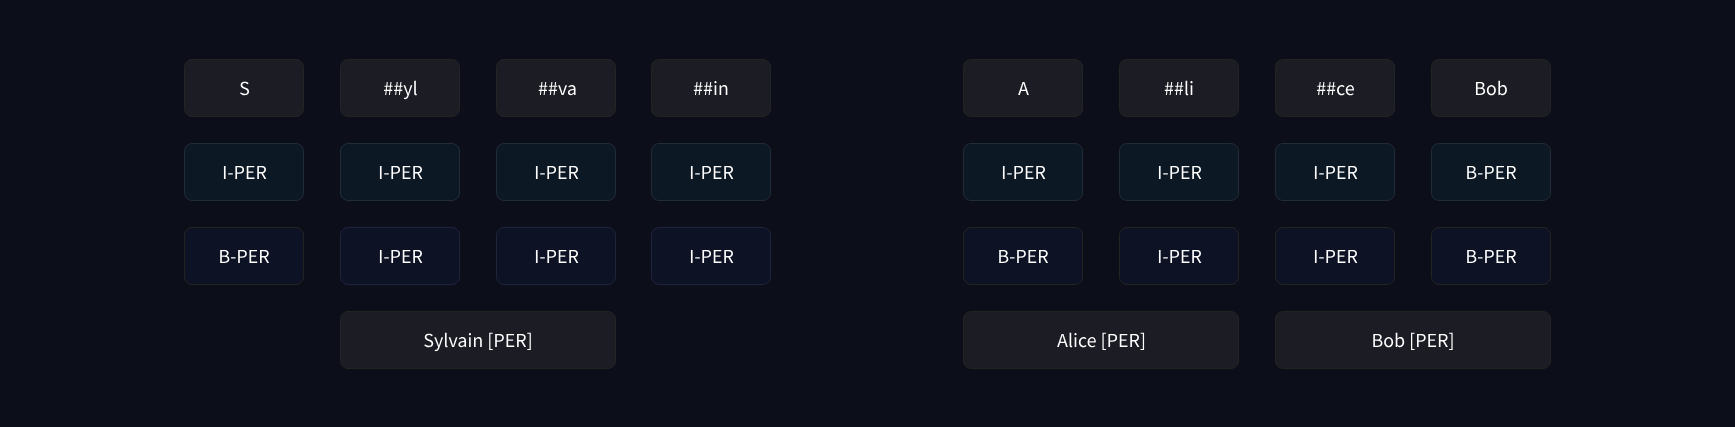

#### Understanding It Properly :-

Let me clarify with an example. Suppose the name is **"Sylvain"** which gets tokenized into `S`, `##yl`, `##va`, `##in`.

**IOB2 format (standard):**
- `S` → `B-PER` (Beginning of person entity)
- `##yl` → `I-PER` (Inside person entity)
- `##va` → `I-PER`
- `##in` → `I-PER`

**IOB1 format (what this model was trained on):**
- `B-` is ONLY used to separate two **adjacent entities of the same type**

So if you have two person names next to each other like **"John Smith"**:
- `John` → `I-PER`
- `Smith` → `I-PER`
- `Barack` → `B-PER` ← B- used here to signal "new entity starting, different from previous"
- `Obama` → `I-PER`

In IOB1, if there's only ONE entity with nothing adjacent to it, it just starts with `I-` directly — no need for `B-` since there's nothing to separate from.

---

So the model wasn't wrong — it was trained on IOB1 where `S` correctly gets `I-PER` because there's no adjacent person entity before it that needs separating. Just a different labeling convention.

With this map, we are ready to reproduce (almost entirely) the results of the first pipeline — we can just grab the score and label of each token that was not classified as `O`:

In [18]:
results = []
tokens = inputs.tokens()

for idx, pred in enumerate(predictions):
    label = model.config.id2label[pred]
    if label != "O":
        results.append(
            {"entity": label, "score": probabilities[idx][pred], "word": tokens[idx]}
        )

results

[{'entity': 'I-PER', 'score': 0.9993828535079956, 'word': 'S'},
 {'entity': 'I-PER', 'score': 0.9981549382209778, 'word': '##yl'},
 {'entity': 'I-PER', 'score': 0.995907187461853, 'word': '##va'},
 {'entity': 'I-PER', 'score': 0.9992327690124512, 'word': '##in'},
 {'entity': 'I-ORG', 'score': 0.9738931059837341, 'word': 'Hu'},
 {'entity': 'I-ORG', 'score': 0.9761149883270264, 'word': '##gging'},
 {'entity': 'I-ORG', 'score': 0.9887976050376892, 'word': 'Face'},
 {'entity': 'I-LOC', 'score': 0.9932106137275696, 'word': 'Brooklyn'}]

This is very similar to what we had before, with one exception: the pipeline also gave us information about the `start` and `end` of each entity in the original sentence. This is where our offset mapping will come into play. To get the offsets, we just have to set `return_offsets_mapping=True` when we apply the tokenizer to our inputs:

In [20]:
inputs_with_offsets = tokenizer(example, return_offsets_mapping=True)
print(inputs_with_offsets["offset_mapping"])

[(0, 0), (0, 2), (3, 7), (8, 10), (11, 12), (12, 14), (14, 16), (16, 18), (19, 22), (23, 24), (25, 29), (30, 32), (33, 35), (35, 40), (41, 45), (46, 48), (49, 57), (57, 58), (0, 0)]


Each tuple is the span of text corresponding to each token, where `(0, 0)` is reserved for the special tokens. We saw before that the token at index 5 is `##yl`, which has `(12, 14)` as offsets here. If we grab the corresponding slice in our example:

In [21]:
example[12:14]

'yl'

we get the proper span of text without the `##` as `##` is added by the tokenizer when making tokens:

In [25]:
print(inputs_with_offsets.tokens())

['[CLS]', 'My', 'name', 'is', 'S', '##yl', '##va', '##in', 'and', 'I', 'work', 'at', 'Hu', '##gging', 'Face', 'in', 'Brooklyn', '.', '[SEP]']


Using this, we can now complete the previous results:

In [27]:
results = []
inputs_with_offsets = tokenizer(example, return_offsets_mapping=True)
tokens = inputs_with_offsets.tokens()
offsets = inputs_with_offsets["offset_mapping"]

for idx, pred in enumerate(predictions):
    label = model.config.id2label[pred]
    if label != "O":
        start, end = offsets[idx]
        results.append(
            {
                "entity": label,
                "score": probabilities[idx][pred],
                "word": tokens[idx],
                "start": start,
                "end": end,
            }
        )

results

[{'entity': 'I-PER',
  'score': 0.9993828535079956,
  'word': 'S',
  'start': 11,
  'end': 12},
 {'entity': 'I-PER',
  'score': 0.9981549382209778,
  'word': '##yl',
  'start': 12,
  'end': 14},
 {'entity': 'I-PER',
  'score': 0.995907187461853,
  'word': '##va',
  'start': 14,
  'end': 16},
 {'entity': 'I-PER',
  'score': 0.9992327690124512,
  'word': '##in',
  'start': 16,
  'end': 18},
 {'entity': 'I-ORG',
  'score': 0.9738931059837341,
  'word': 'Hu',
  'start': 33,
  'end': 35},
 {'entity': 'I-ORG',
  'score': 0.9761149883270264,
  'word': '##gging',
  'start': 35,
  'end': 40},
 {'entity': 'I-ORG',
  'score': 0.9887976050376892,
  'word': 'Face',
  'start': 41,
  'end': 45},
 {'entity': 'I-LOC',
  'score': 0.9932106137275696,
  'word': 'Brooklyn',
  'start': 49,
  'end': 57}]

This is the same as what we got from the first pipeline!

### Grouping entities :-

Using the offsets to determine the start and end keys for each entity is handy, but that information isn’t strictly necessary. When we want to group the entities together, however, the offsets will save us a lot of messy code. For example, if we wanted to group together the tokens `Hu`, `##gging`, and `Face`, we could make special rules that say the first two should be attached while removing the `##`, and the `Face` should be added with a space since it does not begin with `##` — but that would only work for this particular type of tokenizer. We would have to write another set of rules for a SentencePiece or a Byte-Pair-Encoding tokenizer (discussed later in this chapter).

With the offsets, all that custom code goes away: we just can take the span in the original text that begins with the first token and ends with the last token. So, in the case of the tokens `Hu`, `##gging`, and `Face`, we should start at character 33 (the beginning of `Hu`) and end before character 45 (the end of `Face`):

In [29]:
example[33:45]

'Hugging Face'

To write the code that post-processes the predictions while grouping entities, we will group together entities that are consecutive and labeled with `I-XXX`, except for the first one, which can be labeled as `B-XXX` or `I-XXX` (so, we stop grouping an entity when we get a `O`, a new type of entity, or a `B-XXX` that tells us an entity of the same type is starting):

In [31]:
import numpy as np

results = []
inputs_with_offsets = tokenizer(example, return_offsets_mapping=True)
tokens = inputs_with_offsets.tokens()
offsets = inputs_with_offsets["offset_mapping"]

idx = 0
while idx < len(predictions):
    pred = predictions[idx]
    label = model.config.id2label[pred]
    if label != "O":
        # Remove the B- or I-
        label = label[2:]
        start, _ = offsets[idx]

        # Grab all the tokens labeled with I-label
        all_scores = []
        while (
            idx < len(predictions)
            and model.config.id2label[predictions[idx]] == f"I-{label}"
        ):
            all_scores.append(probabilities[idx][pred])
            _, end = offsets[idx]
            idx += 1

        # The score is the mean of all the scores of the tokens in that grouped entity
        score = np.mean(all_scores).item()
        word = example[start:end]
        results.append(
            {
                "entity_group": label,
                "score": score,
                "word": word,
                "start": start,
                "end": end,
            }
        )
    idx += 1

results

[{'entity_group': 'PER',
  'score': 0.9981694370508194,
  'word': 'Sylvain',
  'start': 11,
  'end': 18},
 {'entity_group': 'ORG',
  'score': 0.9796018997828165,
  'word': 'Hugging Face',
  'start': 33,
  'end': 45},
 {'entity_group': 'LOC',
  'score': 0.9932106137275696,
  'word': 'Brooklyn',
  'start': 49,
  'end': 57}]

And we get the same results as with our second pipeline!

Another example of a task where these offsets are extremely useful is question answering.

# Normalization and pre-tokenization :-

Before we dive more deeply into the **three most common subword tokenization algorithms** used with **Transformer models** `(Byte-Pair Encoding [BPE], WordPiece, and Unigram)`, we’ll first take a look at the preprocessing that each tokenizer applies to text. Here’s a high-level overview of the steps in the tokenization pipeline:

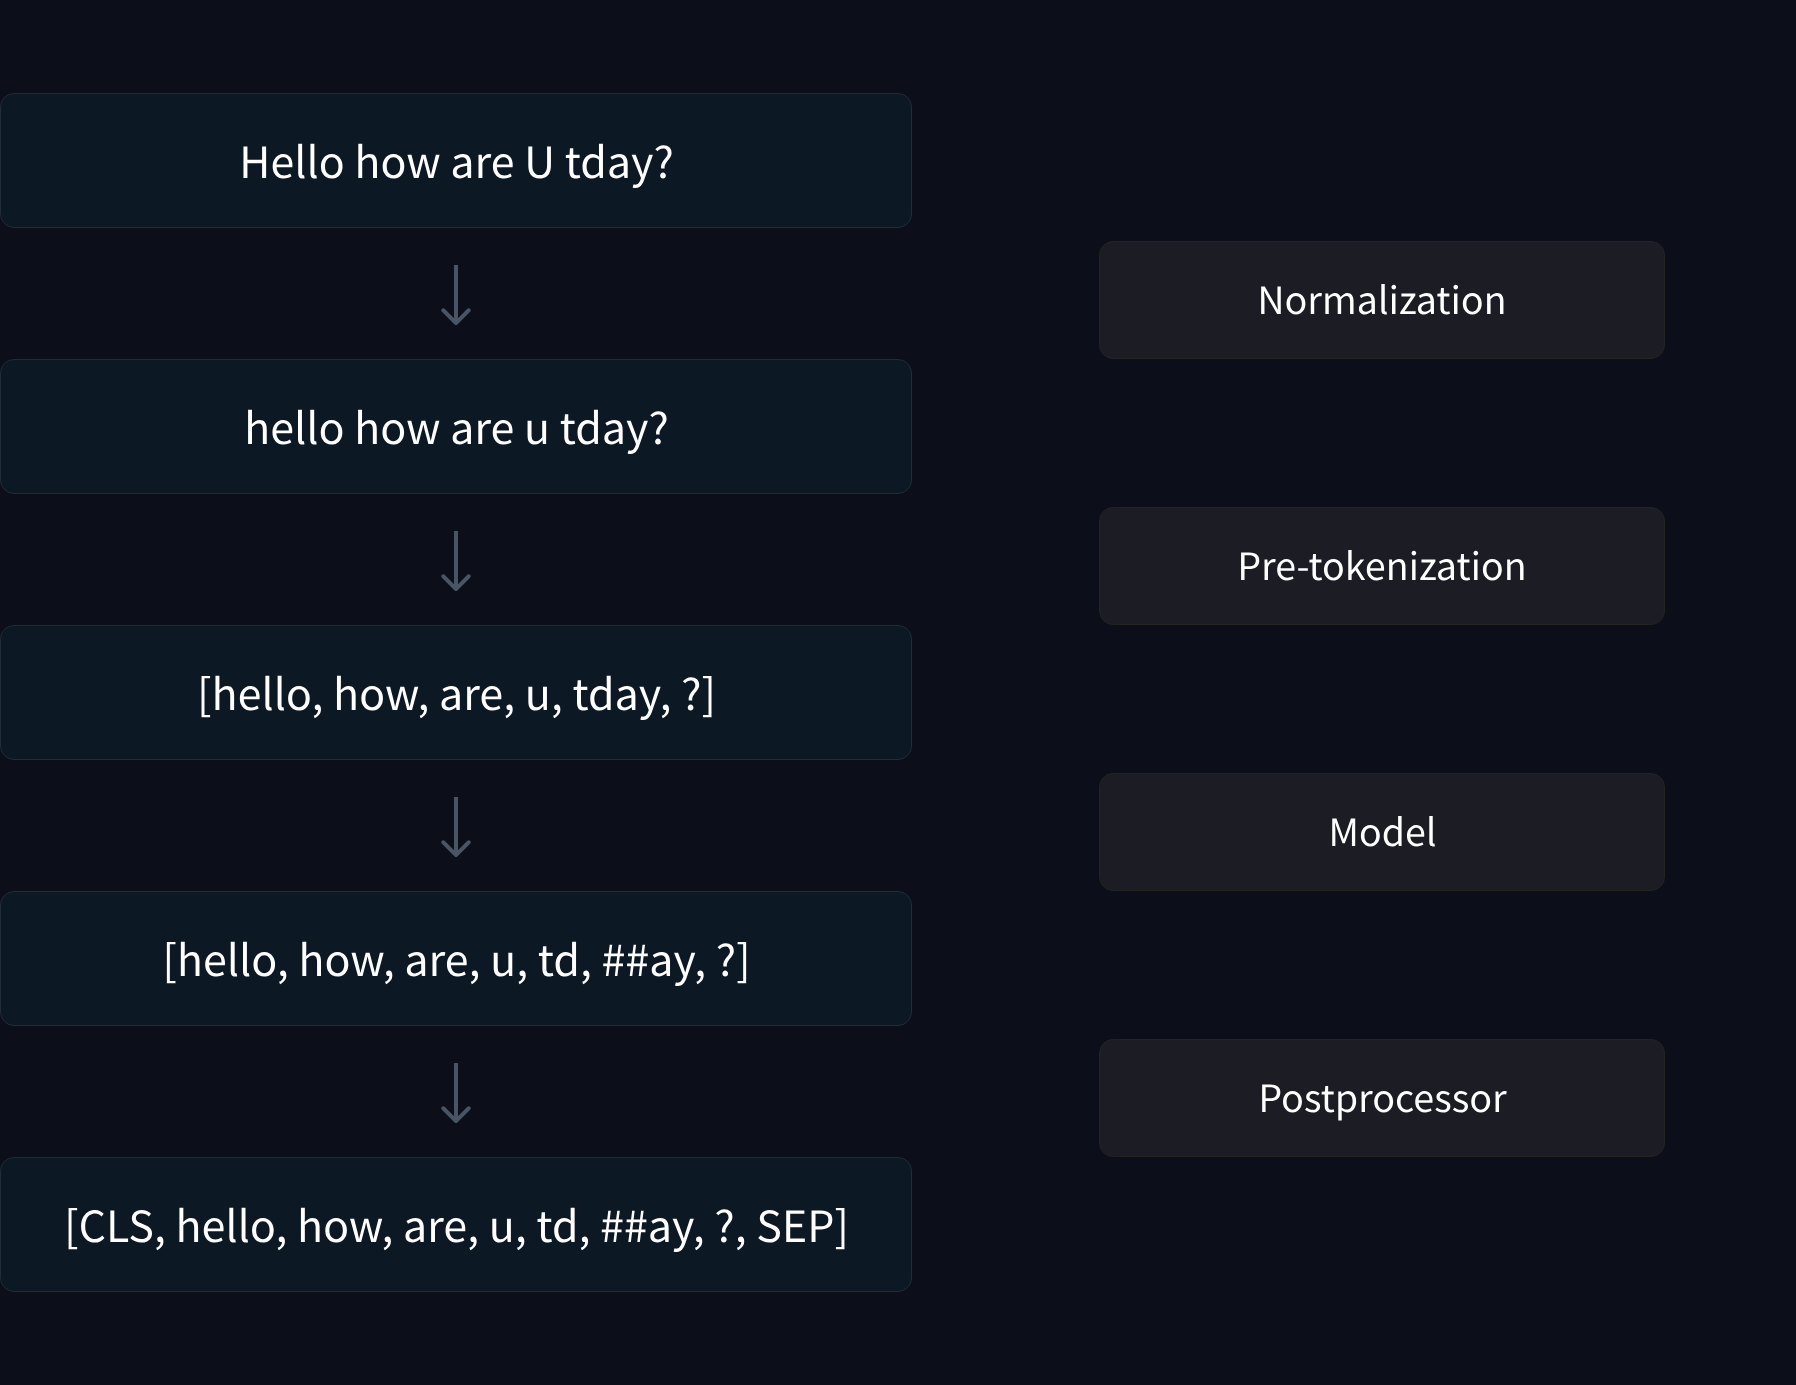

Before splitting a text into subtokens (according to its model), the tokenizer performs two steps: `normalization` and `pre-tokenization`.

## Normalization :-

The normalization step involves some general cleanup, such as removing needless whitespace, lowercasing, and/or removing accents. If you’re familiar with Unicode normalization (such as NFC or NFKC), this is also something the tokenizer may apply.

The 🤗 Transformers `tokenizer` has an attribute called `backend_tokenizer` that provides access to the underlying tokenizer from the 🤗 Tokenizers library:

`backend_tokenizer` is not a separate tokenizer — it's just accessing the **underlying fast implementation** of the same tokenizer.

HuggingFace has two layers:

- **`transformers` library** → the high level Python wrapper you use (`AutoTokenizer` etc)
- **`tokenizers` library** → the low level Rust implementation that actually runs fast under the hood

When you load a fast tokenizer with `AutoTokenizer`, it uses the `tokenizers` library internally for speed. `backend_tokenizer` just gives you **direct access to that underlying Rust tokenizer object** so you can inspect its internals like normalizer, pre-tokenizer etc.

Think of it like a car — `AutoTokenizer` is the steering wheel and dashboard you interact with, `backend_tokenizer` is opening the hood to see the actual engine underneath. Same car, just different level of access.

In [1]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
print(type(tokenizer.backend_tokenizer))

<class 'tokenizers.Tokenizer'>


The `normalizer` attribute of the `tokenizer` object has a `normalize_str()` method that we can use to see how the normalization is performed:

In [7]:
print(tokenizer.backend_tokenizer.normalizer.normalize_str("Héllò hôw are ü?"))

hello how are u?


In this example, since we picked the `bert-base-uncased` checkpoint, the normalization applied lowercasing and removed the accents.

## Pre-tokenization :-

As we will see in the next sections, a tokenizer cannot be trained on raw text alone. Instead, we first need to split the texts into small entities, like words. That’s where the pre-tokenization step comes in. As we saw in Chapter 2, a word-based tokenizer can simply split a raw text into words on whitespace and punctuation. Those words will be the boundaries of the subtokens the tokenizer can learn during its training.

To see how a fast tokenizer performs pre-tokenization, we can use the `pre_tokenize_str()` method of the `pre_tokenizer` attribute of the `tokenizer` object:

In [2]:
tokenizer.backend_tokenizer.pre_tokenizer.pre_tokenize_str("Hello, how are  you?")

[('Hello', (0, 5)),
 (',', (5, 6)),
 ('how', (7, 10)),
 ('are', (11, 14)),
 ('you', (16, 19)),
 ('?', (19, 20))]

Notice how the tokenizer is already keeping track of the offsets, which is how it can give us the offset mapping we used in the previous section. Here the tokenizer ignores the two spaces and replaces them with just one, but the offset jumps between `are` and `you` to account for that.

Since we’re using a `BERT` tokenizer, the pre-tokenization involves splitting on whitespace and punctuation. Other tokenizers can have different rules for this step. For example, if we use the `GPT-2` tokenizer:

In [3]:
tokenizer = AutoTokenizer.from_pretrained("gpt2")
tokenizer.backend_tokenizer.pre_tokenizer.pre_tokenize_str("Hello, how are  you?")

[('Hello', (0, 5)),
 (',', (5, 6)),
 ('Ġhow', (6, 10)),
 ('Ġare', (10, 14)),
 ('Ġ', (14, 15)),
 ('Ġyou', (15, 19)),
 ('?', (19, 20))]

it will split on whitespace and punctuation as well, but it will keep the spaces and replace them with a `Ġ` symbol, enabling it to recover the original spaces if we decode the tokens:

Also note that unlike the `BERT` tokenizer, this tokenizer does not ignore the double space.

For a last example, let’s have a look at the `T5` tokenizer, which is based on the `SentencePiece algorithm`:

In [5]:
tokenizer = AutoTokenizer.from_pretrained("t5-small")
tokenizer.backend_tokenizer.pre_tokenizer.pre_tokenize_str("Hello, how are  you?")

config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

c:\Users\Lenovo\AppData\Local\Programs\Python\Python310\lib\site-packages\huggingface_hub\file_download.py:137: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Lenovo\.cache\huggingface\hub\models--t5-small. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


tokenizer_config.json:   0%|          | 0.00/2.32k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

[('▁Hello,', (0, 6)),
 ('▁how', (7, 10)),
 ('▁are', (11, 14)),
 ('▁you?', (16, 20))]

Like the GPT-2 tokenizer, this one keeps spaces and replaces them with a specific token (`_`), but the T5 tokenizer only splits on whitespace, not punctuation. Also note that it added a space by default at the beginning of the sentence (before `Hello`) and ignored the double space between `are` and `you`.

Now that we’ve seen a little of how some different tokenizers process text, we can start to explore the underlying algorithms themselves. We’ll begin with a quick look at the broadly widely applicable SentencePiece; then, over the next three sections, we’ll examine how the three main algorithms used for subword tokenization work.

## SentencePiece :-

`SentencePiece` is a tokenization algorithm for the preprocessing of text that you can use with any of the models we will see in the next three sections. It considers the text as a sequence of Unicode characters, and replaces spaces with a special character, `▁`. Used in conjunction with the Unigram algorithm, it doesn’t even require a pre-tokenization step, which is very useful for languages where the space character is not used (like Chinese or Japanese).

The other main feature of SentencePiece is **reversible tokenization**: since there is no special treatment of spaces, decoding the tokens is done simply by concatenating them and replacing the `_`s with spaces — this results in the normalized text. As we saw earlier, the BERT tokenizer removes repeating spaces, so its tokenization is not reversible.

## Algorithm overview :-

In the following sections, we’ll dive into the three main **subword tokenization algorithms**: `BPE` (used by GPT-2 and others), `WordPiece` (used for example by BERT), and `Unigram` (used by T5 and others). Before we get started, here’s a quick overview of how they each work.

| Model | BPE | WordPiece | Unigram |
|-------|-----|-----------|----------|
| **Training** | Starts from a small vocabulary and learns rules to merge tokens | Starts from a small vocabulary and learns rules to merge tokens | Starts from a large vocabulary and learns rules to remove tokens |
| **Training step** | Merges the tokens corresponding to the most common pair | Merges the tokens corresponding to the pair with the best score based on the frequency of the pair, privileging pairs where each individual token is less frequent | Removes all the tokens in the vocabulary that will minimize the loss computed on the whole corpus |
| **Learns** | Merge rules and a vocabulary | Just a vocabulary | A vocabulary with a score for each token |
| **Encoding** | Splits a word into characters and applies the merges learned during training | Finds the longest subword starting from the beginning that is in the vocabulary, then does the same for the rest of the word | Finds the most likely split into tokens, using the scores learned during training |

`BPE` and `WordPiece` cover the most commonly used models (GPT family and BERT family). Unigram is less common in practice.

#### Understanding Deeply :-

**First — what is vocabulary?**

Vocabulary is just a fixed lookup table the tokenizer knows about. Every token in it has an ID.

```
"hello" → 1234
"world" → 5678
"un"    → 432
"##happy" → 891
```

If a word isn't in the vocabulary, the tokenizer has to break it into pieces.

---

**Now — what is BPE actually doing?**

The **problem** being solved is:

> "How do I build a vocabulary of say `50,000` tokens that covers language efficiently?"

You can't just list every English word — there are too many, and new words appear constantly. So instead you build tokens from **subword pieces**.

**How BPE builds the vocabulary** (this happens during *training the tokenizer*, not when you use it):

Start with your training text, say:

```
"low lower lowest"
```

Step 1 — split everything into individual characters:

```
l o w
l o w e r
l o w e s t
```

Step 2 — count every adjacent pair:
```
(l,o) → appears 3 times
(o,w) → appears 3 times
(w,e) → appears 2 times
...
```

Step 3 — merge the most frequent pair into one token:
```
lo w
lo w e r
lo w e s t
```

Step 4 — recount, merge again:
```
low
low e r
low e s t
```

Keep repeating until you hit your target vocabulary size. So your vocabulary ends up containing:
```
l, o, w, e, r, s, t, lo, low, lowe, lower ...
```

**Merging = combining two adjacent pieces into one new token and adding it to the vocabulary.**

---

**The key mental model for all three:**

```
Goal → build a vocabulary of subword pieces
       so common words are single tokens
       and rare words get split into recognizable pieces

"unhappiness" → ["un", "happiness"]  or  ["un", "happy", "ness"]
```

The algorithm choice just affects *how* you decide which pieces end up in the vocabulary. When you actually *use* the tokenizer, you just call `tokenizer(text)` and don't think about any of this.

**Quick overview of each:**

* `BPE (Byte Pair Encoding)` → used by GPT-2, RoBERTa. Starts with individual characters, then repeatedly merges the most frequent pairs of tokens until vocabulary size is reached.

* `WordPiece` → used by BERT. Similar to BPE but instead of most frequent pair, merges the pair that **maximizes likelihood** of the training data.

* `Unigram` → used by T5, ALBERT. Works opposite to BPE — starts with a huge vocabulary and keeps **removing** tokens until target size is reached.

Now let’s dive into these 3 subword tokenization algorithms! and start with BPE!

# Byte-Pair Encoding tokenization :-

Byte-Pair Encoding (BPE) was initially developed as an algorithm to compress texts, and then used by OpenAI for tokenization when pretraining the GPT model. It’s used by a lot of Transformer models, including GPT, GPT-2, RoBERTa, BART, and DeBERTa.

## Training algorithm 

BPE training starts by computing the unique set of words used in the corpus (after the normalization and pre-tokenization steps are completed), then building the vocabulary by taking all the symbols used to write those words. As a very simple example, let’s say our corpus uses these five words:

> "hug", "pug", "pun", "bun", "hugs"

The base vocabulary will then be `["b", "g", "h", "n", "p", "s", "u"]`. For real-world cases, that base vocabulary will contain all the ASCII characters, at the very least, and probably some Unicode characters as well. If an example you are tokenizing uses a character that is not in the training corpus, that character will be converted to the unknown token. That’s one reason why lots of NLP models are very bad at analyzing content with emojis, for instance.

> The GPT-2 and RoBERTa tokenizers (which are pretty similar) have a clever way to deal with this: they don’t look at words as being written with Unicode characters, but with bytes. This way the base vocabulary has a small size (256), but every character you can think of will still be included and not end up being converted to the unknown token. This trick is called byte-level BPE.

After getting this base vocabulary, we add new tokens until the desired vocabulary size is reached by learning **merges**, which are rules to merge two elements of the existing vocabulary together into a new one. So, at the beginning these merges will create tokens with two characters, and then, as training progresses, longer subwords.

At any step during the tokenizer training, the BPE algorithm will search for the most frequent pair of existing tokens (by “pair,” here we mean two consecutive tokens in a word). That most frequent pair is the one that will be merged, and we rinse and repeat for the next step.

Going back to our previous example, let’s assume the words had the following frequencies:

> ("hug", 10), ("pug", 5), ("pun", 12), ("bun", 4), ("hugs", 5)

meaning `"hug"` was present `10` times in the corpus, "pug" 5 times, "pun" 12 times, "bun" 4 times, and "hugs" 5 times. We start the training by splitting each word into characters (the ones that form our initial vocabulary) so we can see each word as a list of tokens:

> ("h" "u" "g", 10), ("p" "u" "g", 5), ("p" "u" "n", 12), ("b" "u" "n", 4), ("h" "u" "g" "s", 5)

Then we look at pairs. The pair `("h", "u")` is present in the words `"hug"` and `"hugs"`, so 15 times total in the corpus. It’s not the most frequent pair, though: that honor belongs to `("u", "g")`, which is present in `"hug"`, `"pug"`, and `"hugs"`, for a grand total of 20 times in the vocabulary.

Thus, the first merge rule learned by the tokenizer is `("u", "g") -> "ug"`, which means that "ug" will be added to the vocabulary, and the pair should be merged in all the words of the corpus. At the end of this stage, the vocabulary and corpus look like this:

**Vocabulary:** ["b", "g", "h", "n", "p", "s", "u", "ug"]

**Corpus:** ("h" "ug", 10), ("p" "ug", 5), ("p" "u" "n", 12), ("b" "u" "n", 4), ("h" "ug" "s", 5)

Now we have some pairs that result in a token longer than two characters: the pair `("h", "ug")`, for instance (present 15 times in the corpus). The most frequent pair at this stage is `("u", "n")`, however, present 16 times in the corpus, so the second merge rule learned is `("u", "n") -> "un"`. Adding that to the vocabulary and merging all existing occurrences leads us to:

**Vocabulary:** ["b", "g", "h", "n", "p", "s", "u", "ug", "un"]

**Corpus:** ("h" "ug", 10), ("p" "ug", 5), ("p" "un", 12), ("b" "un", 4), ("h" "ug" "s", 5)

Now the most frequent pair is `("h", "ug")`, so we learn the merge rule `("h", "ug")` -> "hug", which gives us our first three-letter token. After the merge, the corpus looks like this:

**Vocabulary:** ["b", "g", "h", "n", "p", "s", "u", "ug", "un", "hug"]

**Corpus:** ("hug", 10), ("p" "ug", 5), ("p" "un", 12), ("b" "un", 4), ("hug" "s", 5)

And we continue like this until we reach the desired vocabulary size.

## Tokenization algorithm :-

Tokenization follows the training process closely, in the sense that new inputs are tokenized by applying the following steps:

1. Normalization
2. Pre-tokenization
3. Splitting the words into individual characters
4. Applying the merge rules learned in order on those splits

Let’s take the example we used during training, with the three merge rules learned:

`("u", "g") -> "ug"`

`("u", "n") -> "un"`

`("h", "ug") -> "hug"`

The word `"bug"` will be tokenized as `["b", "ug"]`. `"mug"`, however, will be tokenized as `["[UNK]", "ug"]` since the letter `"m"` was not in the base vocabulary. Likewise, the word `"thug"` will be tokenized as `["[UNK]", "hug"]`: the letter `"t"` is not in the base vocabulary, and applying the merge rules results first in `"u"` and `"g"` being merged and then `"h"` and `"ug"` being merged.

## Implementing BPE :-

Now let’s take a look at an implementation of the BPE algorithm. This won’t be an optimized version you can actually use on a big corpus; we just want to show you the code so you can understand the algorithm a little bit better.

First we need a corpus, so let’s create a simple one with a few sentences:

In [32]:
corpus = [
    "This is the Hugging Face Course.",
    "This chapter is about tokenization.",
    "This section shows several tokenizer algorithms.",
    "Hopefully, you will be able to understand how they are trained and generate tokens.",
]

Next, we need to **pre-tokenize** that corpus into words. Since we are replicating a `BPE` tokenizer (like GPT-2), we will use the `gpt2` tokenizer for the pre-tokenization:

In [33]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("gpt2")

Then we compute the frequencies of each word in the corpus as we do the pre-tokenization:

In [34]:
from collections import defaultdict

word_freqs = defaultdict(int)

for text in corpus:
    words_with_offsets = tokenizer.backend_tokenizer.pre_tokenizer.pre_tokenize_str(text)
    new_words = [word for word, offset in words_with_offsets]
    for word in new_words:
        word_freqs[word] += 1

word_freqs

defaultdict(int,
            {'This': 3,
             'Ġis': 2,
             'Ġthe': 1,
             'ĠHugging': 1,
             'ĠFace': 1,
             'ĠCourse': 1,
             '.': 4,
             'Ġchapter': 1,
             'Ġabout': 1,
             'Ġtokenization': 1,
             'Ġsection': 1,
             'Ġshows': 1,
             'Ġseveral': 1,
             'Ġtokenizer': 1,
             'Ġalgorithms': 1,
             'Hopefully': 1,
             ',': 1,
             'Ġyou': 1,
             'Ġwill': 1,
             'Ġbe': 1,
             'Ġable': 1,
             'Ġto': 1,
             'Ġunderstand': 1,
             'Ġhow': 1,
             'Ġthey': 1,
             'Ġare': 1,
             'Ġtrained': 1,
             'Ġand': 1,
             'Ġgenerate': 1,
             'Ġtokens': 1})

The next step is to compute the base vocabulary, formed by all the characters used in the corpus:

In [35]:
alphabet = []

for word in word_freqs.keys():
    for letter in word:
        if letter not in alphabet:
            alphabet.append(letter)
alphabet.sort()

print(alphabet)

[',', '.', 'C', 'F', 'H', 'T', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'k', 'l', 'm', 'n', 'o', 'p', 'r', 's', 't', 'u', 'v', 'w', 'y', 'z', 'Ġ']


We also add the special tokens used by the model at the beginning of that vocabulary. In the case of GPT-2, the only special token is `"<|endoftext|>"`:

In [36]:
vocab = ["<|endoftext|>"] + alphabet.copy()
print(vocab)

['<|endoftext|>', ',', '.', 'C', 'F', 'H', 'T', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'k', 'l', 'm', 'n', 'o', 'p', 'r', 's', 't', 'u', 'v', 'w', 'y', 'z', 'Ġ']


We now need to split each word into individual characters, to be able to start training:

In [37]:
splits = {word: [c for c in word] for word in word_freqs.keys()}
splits

{'This': ['T', 'h', 'i', 's'],
 'Ġis': ['Ġ', 'i', 's'],
 'Ġthe': ['Ġ', 't', 'h', 'e'],
 'ĠHugging': ['Ġ', 'H', 'u', 'g', 'g', 'i', 'n', 'g'],
 'ĠFace': ['Ġ', 'F', 'a', 'c', 'e'],
 'ĠCourse': ['Ġ', 'C', 'o', 'u', 'r', 's', 'e'],
 '.': ['.'],
 'Ġchapter': ['Ġ', 'c', 'h', 'a', 'p', 't', 'e', 'r'],
 'Ġabout': ['Ġ', 'a', 'b', 'o', 'u', 't'],
 'Ġtokenization': ['Ġ',
  't',
  'o',
  'k',
  'e',
  'n',
  'i',
  'z',
  'a',
  't',
  'i',
  'o',
  'n'],
 'Ġsection': ['Ġ', 's', 'e', 'c', 't', 'i', 'o', 'n'],
 'Ġshows': ['Ġ', 's', 'h', 'o', 'w', 's'],
 'Ġseveral': ['Ġ', 's', 'e', 'v', 'e', 'r', 'a', 'l'],
 'Ġtokenizer': ['Ġ', 't', 'o', 'k', 'e', 'n', 'i', 'z', 'e', 'r'],
 'Ġalgorithms': ['Ġ', 'a', 'l', 'g', 'o', 'r', 'i', 't', 'h', 'm', 's'],
 'Hopefully': ['H', 'o', 'p', 'e', 'f', 'u', 'l', 'l', 'y'],
 ',': [','],
 'Ġyou': ['Ġ', 'y', 'o', 'u'],
 'Ġwill': ['Ġ', 'w', 'i', 'l', 'l'],
 'Ġbe': ['Ġ', 'b', 'e'],
 'Ġable': ['Ġ', 'a', 'b', 'l', 'e'],
 'Ġto': ['Ġ', 't', 'o'],
 'Ġunderstand': ['Ġ', 'u', 'n'

Now that we are ready for training, let’s write a function that computes the frequency of each pair. We’ll need to use this at each step of the training:

In [38]:
def compute_pair_freqs(splits):
    pair_freqs = defaultdict(int)
    for word, freq in word_freqs.items():
        split = splits[word]
        if len(split) == 1:
            continue
        for i in range(len(split) - 1):
            pair = (split[i], split[i + 1])
            pair_freqs[pair] += freq
    return pair_freqs

Let’s have a look at a part of this dictionary after the initial splits:

In [39]:
pair_freqs = compute_pair_freqs(splits)

for i, key in enumerate(pair_freqs.keys()):
    print(f"{key}: {pair_freqs[key]}")
    if i >= 5:
        break

('T', 'h'): 3
('h', 'i'): 3
('i', 's'): 5
('Ġ', 'i'): 2
('Ġ', 't'): 7
('t', 'h'): 3


Now, finding the most frequent pair only takes a quick loop:

In [40]:
best_pair = ""
max_freq = None

for pair, freq in pair_freqs.items():
    if max_freq is None or max_freq < freq:
        best_pair = pair
        max_freq = freq

print(best_pair, max_freq)

('Ġ', 't') 7


So the first merge to learn is `('Ġ', 't') -> 'Ġt'`, and we add `'Ġt'` to the vocabulary:

In [41]:
merges = {("Ġ", "t"): "Ġt"}
vocab.append("Ġt")

To continue, we need to apply that merge in our splits dictionary. Let’s write another function for this:

In [42]:
def merge_pair(a, b, splits):
    for word in word_freqs:
        split = splits[word]
        if len(split) == 1:
            continue

        i = 0
        while i < len(split) - 1:
            if split[i] == a and split[i + 1] == b:
                split = split[:i] + [a + b] + split[i + 2 :]
            else:
                i += 1
        splits[word] = split
    return splits

And we can have a look at the result of the first merge:

In [43]:
splits = merge_pair("Ġ", "t", splits)
print(splits["Ġtrained"])

['Ġt', 'r', 'a', 'i', 'n', 'e', 'd']


Now we have everything we need to loop until we have learned all the merges we want. Let’s aim for a vocab size of 50:

In [44]:
vocab_size = 50

while len(vocab) < vocab_size:
    pair_freqs = compute_pair_freqs(splits)
    best_pair = ""
    max_freq = None
    for pair, freq in pair_freqs.items():
        if max_freq is None or max_freq < freq:
            best_pair = pair
            max_freq = freq
    splits = merge_pair(*best_pair, splits)
    merges[best_pair] = best_pair[0] + best_pair[1]
    vocab.append(best_pair[0] + best_pair[1])

As a result, we’ve learned 19 merge rules (the initial vocabulary had a size of 31 — 30 characters in the alphabet, plus the special token):

In [45]:
print(merges)

{('Ġ', 't'): 'Ġt', ('i', 's'): 'is', ('e', 'r'): 'er', ('Ġ', 'a'): 'Ġa', ('Ġt', 'o'): 'Ġto', ('e', 'n'): 'en', ('T', 'h'): 'Th', ('Th', 'is'): 'This', ('o', 'u'): 'ou', ('s', 'e'): 'se', ('Ġto', 'k'): 'Ġtok', ('Ġtok', 'en'): 'Ġtoken', ('n', 'd'): 'nd', ('Ġ', 'is'): 'Ġis', ('Ġt', 'h'): 'Ġth', ('Ġth', 'e'): 'Ġthe', ('i', 'n'): 'in', ('Ġa', 'b'): 'Ġab', ('Ġtoken', 'i'): 'Ġtokeni'}


And the vocabulary is composed of the special token, the initial alphabet, and all the results of the merges:

In [46]:
print(vocab)

['<|endoftext|>', ',', '.', 'C', 'F', 'H', 'T', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'k', 'l', 'm', 'n', 'o', 'p', 'r', 's', 't', 'u', 'v', 'w', 'y', 'z', 'Ġ', 'Ġt', 'is', 'er', 'Ġa', 'Ġto', 'en', 'Th', 'This', 'ou', 'se', 'Ġtok', 'Ġtoken', 'nd', 'Ġis', 'Ġth', 'Ġthe', 'in', 'Ġab', 'Ġtokeni']


> 💡 `Using train_new_from_iterator()` on the same corpus won’t result in the exact same vocabulary. This is because when there is a choice of the most frequent pair, we selected the first one encountered, while the 🤗 Tokenizers library selects the first one based on its inner IDs.

To tokenize a new text, we pre-tokenize it, split it, then apply all the merge rules learned:

In [47]:
def tokenize(text):
    pre_tokenize_result = tokenizer._tokenizer.pre_tokenizer.pre_tokenize_str(text)
    pre_tokenized_text = [word for word, offset in pre_tokenize_result]
    splits = [[l for l in word] for word in pre_tokenized_text]
    for pair, merge in merges.items():
        for idx, split in enumerate(splits):
            i = 0
            while i < len(split) - 1:
                if split[i] == pair[0] and split[i + 1] == pair[1]:
                    split = split[:i] + [merge] + split[i + 2 :]
                else:
                    i += 1
            splits[idx] = split

    return sum(splits, [])

We can try this on any text composed of characters in the alphabet:

In [48]:
tokenize("This is not a token.")

['This', 'Ġis', 'Ġ', 'n', 'o', 't', 'Ġa', 'Ġtoken', '.']

> ⚠️ Our implementation will throw an error if there is an unknown character since we didn’t do anything to handle them. GPT-2 doesn’t actually have an unknown token (it’s impossible to get an unknown character when using byte-level BPE), but this could happen here because we did not include all the possible bytes in the initial vocabulary. This aspect of BPE is beyond the scope of this section, so we’ve left the details out.

That’s it for the BPE algorithm!

> **`Note:`** Next 2 algorithms are `WordPiece` and `Unigram` and to deep dive in them is not necessary, just having the overview of them is enough so we can skim it.

# Building a tokenizer, block by block

As we’ve seen in the previous sections, tokenization comprises several steps:

* Normalization (any cleanup of the text that is deemed necessary, such as removing spaces or accents, Unicode normalization, etc.)

* Pre-tokenization (splitting the input into words)

* Running the input through the model (using the pre-tokenized words to produce a sequence of tokens)

* Post-processing (adding the special tokens of the tokenizer, generating the attention mask and token type IDs)

> **`Note:`** You would barely build your own tokenizer from scratch so deep diving in it ain't necessary and can be skipped.